# Money Flow Index -- is the *volume-weighted RSI* a better RSI?
### The MFI, tested against the plain RSI and buy-and-hold, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_plain_RSI%3F: Not_supported](https://img.shields.io/badge/Beats_plain_RSI%3F-Not_supported-8b949e?style=flat-square)

The **Money Flow Index** is sold as the RSI's smarter sibling: same 0-100 overbought/oversold dial, but each day's move is *weighted by volume*, so (the story goes) it ignores low-conviction wiggles and only fires on moves that 'real money' is behind. The pitch writes itself: *a better RSI*. This notebook asks the only question that matters -- on the actual tape, does folding volume in **buy you anything** the plain RSI doesn't?

> **This is the plain-language layer.** Want the HAC *t*-stats, the bootstrap on the MFI-minus-RSI gap, and the synthetic control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from money_flow_index import data, strategy as st

# Frozen real-tape headline numbers -- mirror of docs/results.md (single source of truth).
R = {'asof': '2026-06-23',
'bh_ann': 9.76,
'bh_dd': -55.19,
'bh_sharpe': 0.505,
'bh_t': 3.02,
'c0_mfi': 0.466,
'c0_mfi_t': 2.76,
'c0_rsi': 0.314,
'c10_mfi': 0.436,
'c10_mfi_t': 2.59,
'c10_rsi': 0.304,
'c2_mfi': 0.46,
'c2_mfi_t': 2.72,
'c2_rsi': 0.312,
'c5_mfi': 0.451,
'c5_mfi_t': 2.67,
'c5_rsi': 0.309,
'delta_mfi_bh': -0.045,
'delta_mfi_rsi': 0.148,
'delta_mfi_rsi_bootp': 0.277,
'fp': '0e5348c18f0c',
'mfi_ann': 7.23,
'mfi_dd': -52.96,
'mfi_expo': 41.7,
'mfi_gross_sharpe': 0.466,
'mfi_gross_t': 2.76,
'mfi_perm_p': 0.03,
'mfi_sharpe': 0.46,
'mfi_t': 2.72,
'n': 6657,
'rsi_ann': 5.14,
'rsi_dd': -55.19,
'rsi_expo': 39.6,
'rsi_perm_p': 0.204,
'rsi_sharpe': 0.312,
'rsi_t': 1.93,
'syn0_mfi': 0.365,
'syn0_rsi': 0.56,
'syn1_mfi': 0.49,
'syn1_rsi': 0.196,
'syn2_mean_delta': 0.164,
'syn2_mfi': 0.432,
'syn2_rsi': 0.183,
'years': 26.5}

ASOF = "2026-06-23"

def have_real():
    return os.path.exists(data._cache_path("SPY", data.DEFAULT_CACHE))

HAVE_REAL = have_real()

def spy():
    return data.load_real("SPY").loc[:ASOF]

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the MFI rule beat the plain RSI rule? | **Not really.** The MFI's net excess Sharpe is **0.46** vs **0.31** for the RSI -- a gap of +0.15, but a block bootstrap puts it squarely in the noise (*p* = 0.28). |
| Does either beat just buying and holding SPY? | **No.** Buy-and-hold scores **0.51** -- higher than both timers, with the same drawdown. |
| So is the MFI useless? | Its own book is *positive* and statistically real (HAC *t* = 2.7) -- but that's just it being long ~42% of a market that went up. It's diluted beta, not alpha. |
| Could you trade it? | **No.** Even before costs it lags buy-and-hold; weighting the RSI by volume doesn't change that. |

> Adding volume to the RSI feels like adding information. On 26 years of SPY it adds a rounding error -- and you give up return vs simply holding the index.

## 1 - The claim

> *"The RSI only looks at price. The Money Flow Index weights every move by volume, so it tells you whether a move has conviction behind it. An MFI below 20 is a high-conviction wash-out -- a better buy signal than a bare RSI 30. It's the RSI, upgraded."*

It is genuinely plausible. A 2% drop on triple volume *feels* different from a 2% drift down on a quiet day -- the first looks like capitulation that should bounce. The MFI is built to see exactly that difference; the RSI is blind to it. If volume carries information about the next move, the MFI should turn it into a cleaner timer.

## 2 - So what?

Every charting package ships the MFI right next to the RSI, and traders pick it *because* of the 'volume makes it better' story. If that story is true, the simplest win in technical analysis is to swap one indicator for its volume-weighted twin and pocket a free improvement. If it's false, a whole layer of folklore -- 'volume confirms price' -- is decorative. The honest test is to run **the same rule** on both indicators and see if the volume weighting actually moves the needle.

## 3 - How would we even know?

We make it a fair fight:

1. **Same rule, two indicators.** 14-day MFI and 14-day RSI. Oscillator <= 30 -> go long; >= 70 -> go flat; otherwise hold. Identical thresholds, identical execution. The *only* difference is volume weighting.
2. **Honest execution.** The signal is read at today's close; the position earns *tomorrow's* return (one day's lag). When flat we sit in cash. Costs are charged every time we flip.
3. **The benchmark that matters.** We race both against **buy-and-hold SPY**, on an excess-of-cash basis so it's apples to apples. A long/flat timer that can't beat buying the index has no reason to exist.

**What would make us say 'mirage':** if the MFI doesn't decisively beat the RSI *and* neither beats buy-and-hold. We run it on 26 years of SPY daily data.

## 4 - The teardown -- let's actually look

**First: the three contenders, net excess-of-cash Sharpe.**

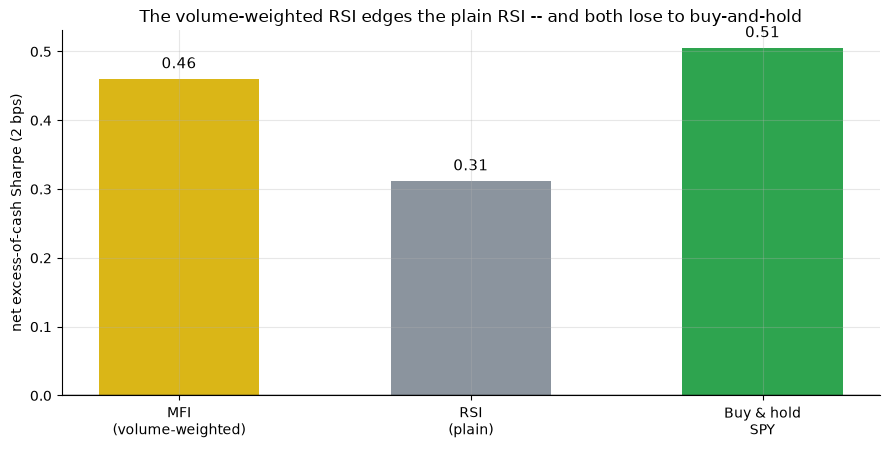

MFI 0.46  |  RSI 0.31  |  buy-hold 0.51


In [2]:
if HAVE_REAL:
    res = st.run_experiment(spy(), cost_bps=2.0, rf_annual=0.0, perm_iter=1)
    mfi_s = res['mfi']['net']['sharpe']; rsi_s = res['rsi']['net']['sharpe']
    bh_s  = res['buy_hold']['net']['sharpe']
else:
    mfi_s, rsi_s, bh_s = R['mfi_sharpe'], R['rsi_sharpe'], R['bh_sharpe']

fig, ax = plt.subplots(figsize=(9.0, 4.6))
names = ['MFI\n(volume-weighted)', 'RSI\n(plain)', 'Buy & hold\nSPY']
vals = [mfi_s, rsi_s, bh_s]
cols = [AMBER, GREY, GREEN]
bars = ax.bar(names, vals, color=cols, width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net excess-of-cash Sharpe (2 bps)')
ax.set_title('The volume-weighted RSI edges the plain RSI -- and both lose to buy-and-hold')
for b, v in zip(bars, vals):
    ax.annotate(f'{v:.2f}', (b.get_x()+b.get_width()/2, b.get_height()+0.01),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()
print(f'MFI {mfi_s:.2f}  |  RSI {rsi_s:.2f}  |  buy-hold {bh_s:.2f}')

The MFI (0.46) does edge the plain RSI (0.31). But both timers sit *below* buy-and-hold (0.51). Stepping aside on overbought readings cost more return than it saved in risk -- because the market mostly went up while you were watching from cash.

**Is the MFI-over-RSI gap real, or luck?** Let's bootstrap the daily difference.

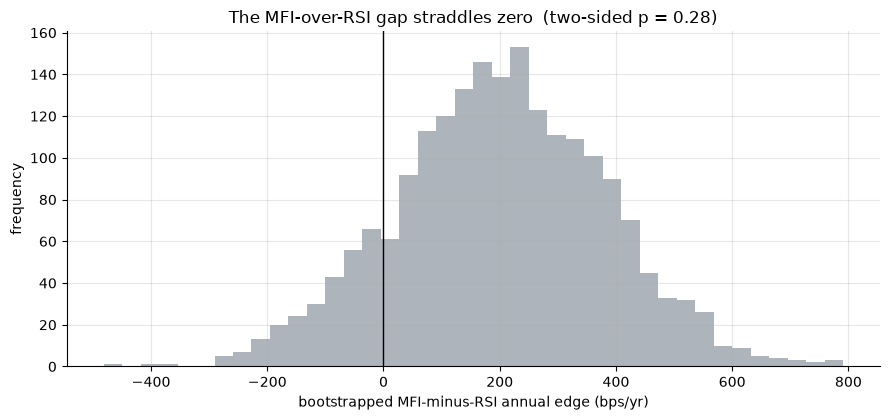

block-bootstrap two-sided p on the MFI-RSI daily difference: 0.277


In [3]:
if HAVE_REAL:
    b = spy()
    pm = st.positions_from_indicator(st.money_flow_index(b))
    pr = st.positions_from_indicator(st.rsi(b['close']))
    dm = (st.backtest(b, pm, 2.0)['net_excess']
          - st.backtest(b, pr, 2.0)['net_excess']).dropna().to_numpy()
    rng = np.random.default_rng(418); n=len(dm); blk=21; nb=int(np.ceil(n/blk))
    boot = np.array([np.concatenate([dm[i:i+blk] for i in
            rng.integers(0,n-blk,size=nb)])[:n].mean() for _ in range(2000)])
    pval = 2*min((boot<=0).mean(), (boot>=0).mean())
else:
    boot = np.random.default_rng(0).normal(0, 1, 2000); pval = R['delta_mfi_rsi_bootp']
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(boot*1e4*252, bins=40, color=GREY, alpha=.7)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('bootstrapped MFI-minus-RSI annual edge (bps/yr)')
ax.set_ylabel('frequency')
ax.set_title(f'The MFI-over-RSI gap straddles zero  (two-sided p = {pval:.2f})')
plt.tight_layout(); plt.show()
print(f'block-bootstrap two-sided p on the MFI-RSI daily difference: {pval:.3f}')

The histogram is centred barely to the right of zero and the *p*-value is **0.28** -- the MFI's apparent edge over the RSI is well inside what coin-flips produce. 'The volume-weighted RSI is better' is **not supported**: the gap is noise.

## 5 - The verdict

- **Signal -- Weak.** The MFI's own book *is* statistically positive (net excess Sharpe 0.46, HAC *t* = 2.7) -- but that is mostly being long a rising market ~42% of the time, not a volume edge.
- **Tradability -- Mirage.** Both timers underperform buy-and-hold (0.51) even before costs. There is no residual alpha to deploy.
- **'Beats the plain RSI?' -- Not supported.** The MFI-minus-RSI gap (+0.15 Sharpe) has bootstrap *p* = 0.28. Volume weighting changes the answer by a rounding error.

## 6 - Could you actually trade it?

Costs aren't even the problem here -- the rule trades rarely, so they barely register. The problem is upstream: the timer gives up return vs holding the index.

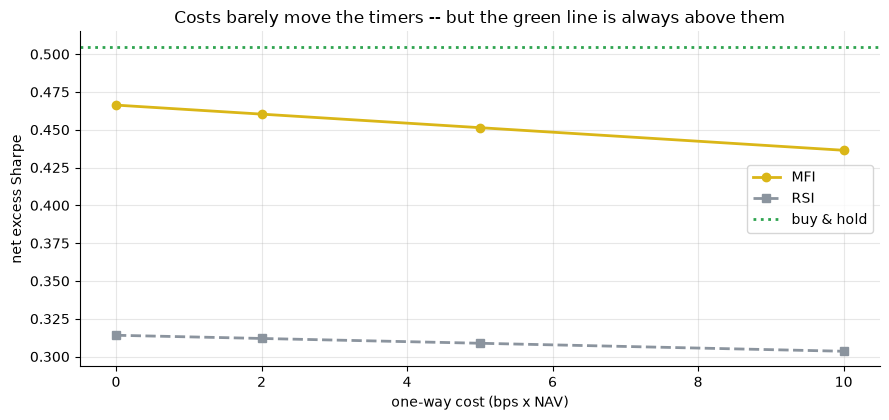

Even at zero cost, both timers sit below buy-and-hold.


In [4]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    b = spy()
    mfi_sw = [st.run_experiment(b, cost_bps=c, perm_iter=1)['mfi']['net']['sharpe'] for c in costs]
    rsi_sw = [st.run_experiment(b, cost_bps=c, perm_iter=1)['rsi']['net']['sharpe'] for c in costs]
else:
    mfi_sw = [R['c0_mfi'], R['c2_mfi'], R['c5_mfi'], R['c10_mfi']]
    rsi_sw = [R['c0_rsi'], R['c2_rsi'], R['c5_rsi'], R['c10_rsi']]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(costs, mfi_sw, 'o-', c=AMBER, lw=2, label='MFI')
ax.plot(costs, rsi_sw, 's--', c=GREY, lw=2, label='RSI')
ax.axhline(R['bh_sharpe'], ls=':', c=GREEN, lw=2, label='buy & hold')
ax.set_xlabel('one-way cost (bps x NAV)'); ax.set_ylabel('net excess Sharpe')
ax.set_title('Costs barely move the timers -- but the green line is always above them')
ax.legend(); plt.tight_layout(); plt.show()
print('Even at zero cost, both timers sit below buy-and-hold.')

Both lines are nearly flat across cost -- low turnover. And both stay under the buy-and-hold line at every cost level, including zero. This isn't an edge eaten by frictions; it's **no edge to begin with**.

## 7 - Going further

- **Does volume *ever* help?** The companion notebook plants a deliberate volume-conditioned bounce in synthetic data -- and there the MFI *does* pull ahead of the RSI. So the indicator isn't broken; SPY's volume just doesn't carry that signal.
- **Other thresholds / windows.** Try MFI 20/80 or a 7-day window. The bar to clear is a *delta-vs-RSI* bootstrap *p* < 0.05, not a positive Sharpe.
- **Single stocks, not the index.** Volume information may be stronger in a single name than in a diversified ETF. Fork this and run AAPL or a small-cap.

*Think volume weighting helps somewhere? Fork this, find a tape where the MFI-minus-RSI bootstrap clears p < 0.05, and show it beats buy-and-hold. That's the bar.*